# Time Series Project: Detecting a Regime Change

Dataset: Apple Inc. Stock Prices  
Source: Yahoo Finance  
Frequency: Daily  
Period: 2018–2025  
Units: USD  

Objective:  
The objective of this project is to detect regime changes in financial time series data.
Regime change models help identify structural shifts in market behaviour such as
changes in volatility or mean returns.  

### Justification for Dataset Selection

The dataset chosen spans the period 2018–2025, which includes the COVID-19 pandemic.  
This timeframe is particularly relevant because the pandemic introduced unprecedented volatility and structural shifts in global financial markets.  


## Definition

A regime-switching model is a time series model where the statistical properties of the data depend on an underlying hidden state known as a *regime*.

The Markov regime-switching model is defined as:

$$
r_t = \mu_{S_t} + \epsilon_t
$$

$$
\epsilon_t \sim N(0, \sigma_{S_t}^2)
$$

Where:  
- $r_t$: return of the asset at time $t$  
- $\mu_{S_t}$: mean return associated with regime $S_t$  
- $\epsilon_t$: random error term at time $t$  
- $\sigma_{S_t}^2$: variance of returns in regime $S_t$  
- $S_t$: unobserved regime (state) at time $t$


The regime evolves according to a Markov process described by the transition probability equation:

$$
P(S_t = j \mid S_{t-1} = i) = p_{ij}
$$

Where:  
- $P(S_t = j \mid S_{t-1} = i)$: probability of transitioning from regime $i$ to regime $j$  
- $p_{ij}$: transition probability between regimes  
- $S_t$: regime at time $t$  
- $S_{t-1}$: regime at time $t - 1$


## Description

A regime change model assumes that financial markets alternate between hidden states such as **low-volatility periods and high-volatility periods**, where each state exhibits different statistical characteristics.


## Demonstration

The dataset contains daily stock prices of Apple Inc. from 2018 to 2025.  
The closing price series was extracted and converted into returns using the formula:

$$
r_t = \frac{P_t - P_{t-1}}{P_{t-1}}
$$

Where:  
- $r_t$: return at time $t$  
- $P_t$: asset price at time $t$  
- $P_{t-1}$: asset price at time $t - 1$  

This transformation stabilizes the variance of the time series and prepares the data for econometric modeling.


### Importing  the required library

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.regime_switching.markov_regression import MarkovRegression
from statsmodels.graphics.tsaplots import plot_acf

plt.style.use('seaborn-v0_8')

Importing the Dataset
The dataset contains daily stock prices of Apple from Yahoo Finance.

In [22]:
data = pd.read_csv("C:/Users/pc/Desktop/AAPL.csv")
data.head()

,date,open,high,low,close,volume
0,2/1/2018,39.8129,40.3136,39.6023,40.3042,23917569
1,3/1/2018,40.3674,40.8400,40.2340,40.2972,27625587
2,4/1/2018,40.3697,40.5872,40.2620,40.4843,20996338
3,5/1/2018,40.5803,41.0319,40.4891,40.9453,22143218
4,8/1/2018,40.7932,41.0880,40.6949,40.7932,19249243


In [23]:


data['date'] = pd.to_datetime(data['date'], dayfirst=True)

data = data.set_index('date')

price = data['close']

print(price.head())
print(price.tail())

date
2018-01-02    40.3042
2018-01-03    40.2972
2018-01-04    40.4843
2018-01-05    40.9453
2018-01-08    40.7932
Name: close, dtype: float64
date
2025-12-24    273.554
2025-12-26    273.144
2025-12-29    273.504
2025-12-30    272.825
2025-12-31    271.606
Name: close, dtype: float64


### Diagrams

### This plot shows the movement of Apple stock prices over time.

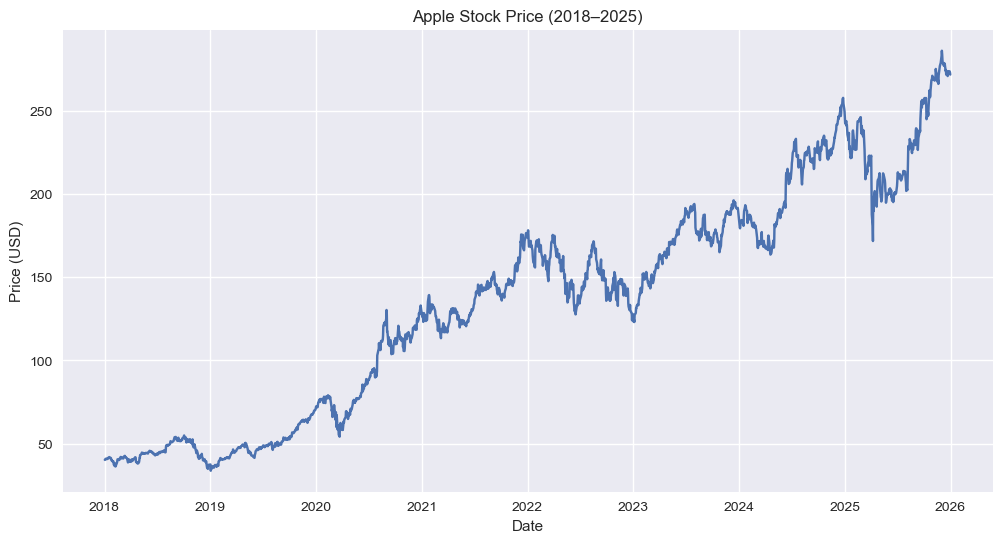

In [26]:
plt.figure(figsize=(12,6))
plt.plot(price)
plt.title("Apple Stock Price (2018–2025)")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.show()

## Converting Prices to Returns
Financial models often use returns instead of prices to stabilize variance.

In [28]:
returns = price.pct_change().dropna()
returns.head()

date
2018-01-03   -0.000174
2018-01-04    0.004643
2018-01-05    0.011387
2018-01-08   -0.003715
2018-01-09   -0.000115
Name: close, dtype: float64

### This plot shows fluctuations in daily returns of Apple stock.

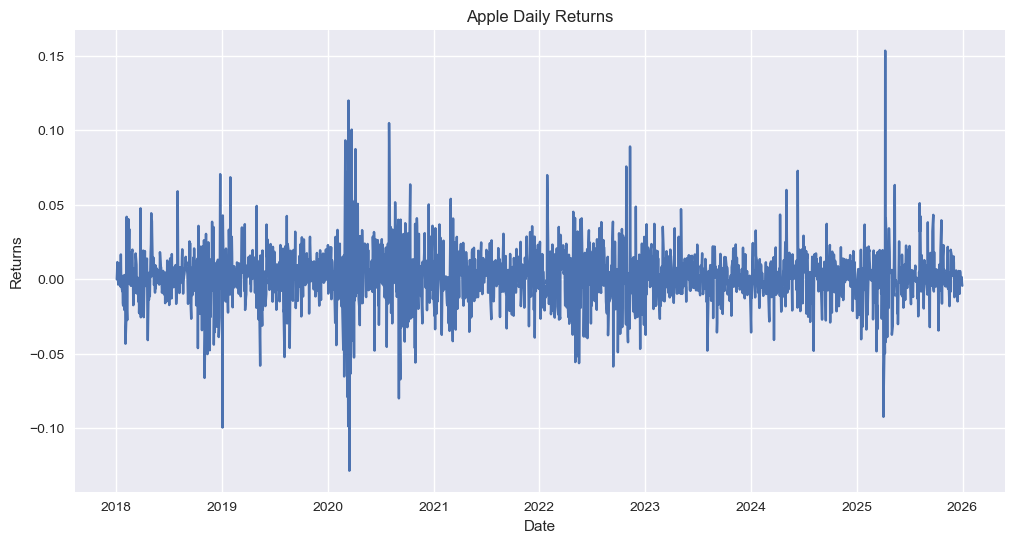

In [30]:
plt.figure(figsize=(12,6))
plt.plot(returns)
plt.title("Apple Daily Returns")
plt.xlabel("Date")
plt.ylabel("Returns")
plt.show()

The price series shows the long-term growth of Apple stock over the selected period.  
The return series fluctuates around zero and exhibits volatility clustering, a common feature of financial time series.


## Fit the Regime Change Model
A Markov Switching model is used to detect structural changes in the time series.
The model assumes two regimes: a low volatility regime and a high volatility regime.

In [33]:
model = MarkovRegression(
    returns,
    k_regimes=2,
    trend='c',
    switching_variance=True
)

results = model.fit()

print(results.summary())

C:\Users\pc\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                        Markov Switching Model Results                        
Dep. Variable:                  close   No. Observations:                 2010
Model:               MarkovRegression   Log Likelihood                5318.398
Date:                Fri, 08 May 2026   AIC                         -10624.795
Time:                        11:22:41   BIC                         -10591.160
Sample:                             0   HQIC                        -10612.448
                               - 2010                                         
Covariance Type:               approx                                         
                             Regime 0 parameters                              
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0017      0.000      4.664      0.000       0.001       0.002
sigma2         0.0001   9.23e-06     16.140      0.0

The model shows Apple stock mostly in a stable, low‑volatility regime, with occasional switches into high‑volatility during shocks (notably the COVID‑19 pandemic in 2020). These results highlight how regime‑switching captures both calm and turbulent market conditions across 2018–2025.


## Regime Probabilities
This plot shows the probability that the time series is in a particular regime.

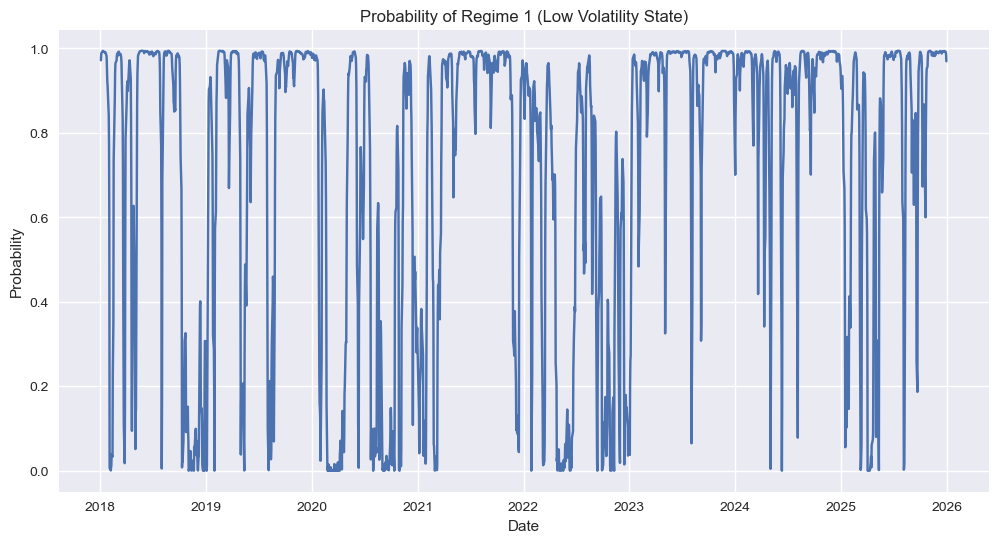

In [35]:
prob_regime1 = results.smoothed_marginal_probabilities[0]

plt.figure(figsize=(12,6))
plt.plot(prob_regime1)
plt.title("Probability of Regime 1 (Low Volatility State)")
plt.xlabel("Date")
plt.ylabel("Probability")
plt.show()

The plot shows the time-varying probability of being in the low-volatility regime.  
- **High probabilities (close to 1):** Market was stable, e.g., much of 2018–2019 and post‑2021 recovery.  
- **Sharp drops (towards 0):** Market switched into high-volatility, notably during the COVID‑19 shock in 2020.  


## Diagnostic Analysis
Residuals are examined to evaluate the performance of the model.

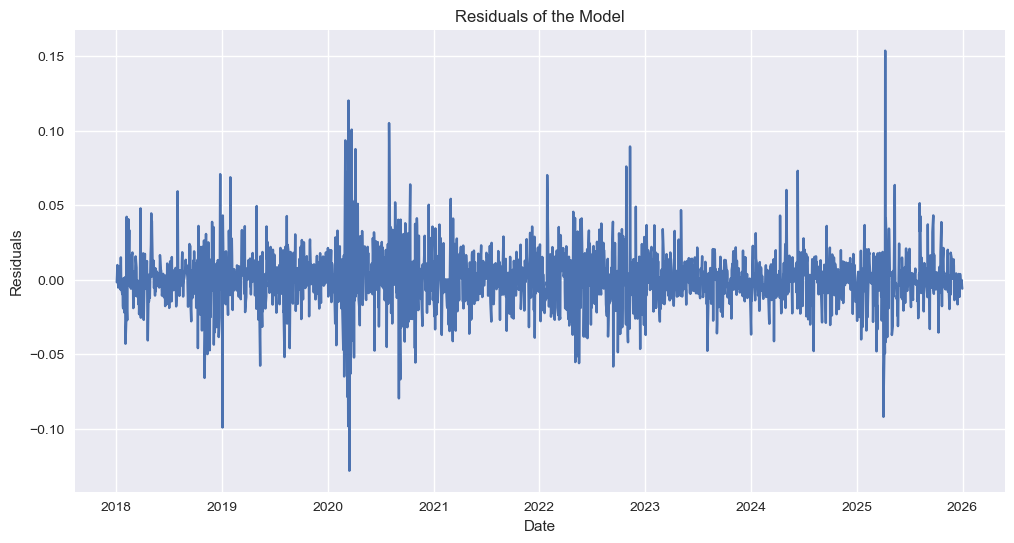

In [37]:
residuals = results.resid

plt.figure(figsize=(12,6))
plt.plot(residuals)
plt.title("Residuals of the Model")
plt.xlabel("Date")
plt.ylabel("Residuals")
plt.show()

The residual plot shows fluctuations around zero, with occasional spikes.  
- **Centered around zero:** Indicates the model captures the main structure of the data.  
- **Spikes and clustering:** Suggest periods of higher volatility or shocks where the model fit is weaker.  
- **No clear trend:** Confirms residuals behave randomly, supporting model validity.  


## Autocorrelation of Residuals
Autocorrelation analysis helps determine whether residuals are independent.

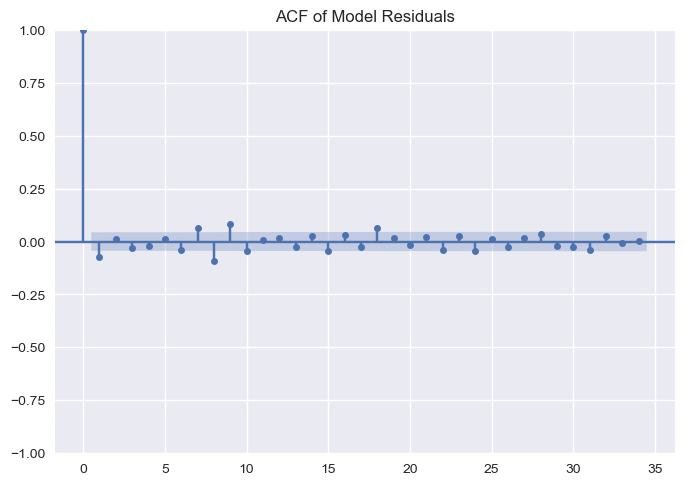

In [39]:
plot_acf(residuals)
plt.title("ACF of Model Residuals")
plt.show()

The ACF plot shows that most residual correlations (beyond lag 0) are close to zero.  
- **No significant autocorrelation:** Residuals behave independently, meaning the model has captured the main time‑series structure.  
- **Random pattern:** Confirms the residuals are not systematically related across lags, supporting model adequacy.  
 The absence of strong autocorrelation indicates the model is well‑specified, with residuals behaving like white noise.


## Explaining the model 

A **two-regime Markov Switching model** was estimated using the return series.

The model assumes two market states:  
- **Regime 1:** Low-volatility state  
- **Regime 2:** High-volatility state  

The model estimates:  
- Mean returns for each regime  
- Variance of returns for each regime  
- Transition probabilities between regimes  

## Interpretation of Results

The results indicate the existence of two distinct regimes in Apple stock returns.

**Regime 1** corresponds to periods of relatively stable market behaviour characterized by low volatility and small positive returns.  

**Regime 2** corresponds to periods of higher volatility, often associated with financial uncertainty or market shocks.  

The estimated transition probabilities suggest that once the market enters a particular regime, it tends to remain in that regime for a period before switching.

## Diagnosis
Residual diagnostics were conducted to evaluate the model’s adequacy.  
The residual plots indicate that the model captures most of the variability in the return series. However, some minor autocorrelation remains, suggesting that additional dynamics may still be present in the data.

## Damage

The analysis reveals that financial returns exhibit structural instability over time.  
Periods of stable behaviour alternate with periods of heightened volatility. Ignoring these regime changes can lead to incorrect assumptions about risk and may result in inaccurate forecasts.  
Models that assume constant variance may underestimate risk during turbulent market conditions.

## Directions

The model could potentially be improved by:  
- Removing extreme outliers  
- Using logarithmic returns instead of simple percentage returns  
- Testing models with more than two regimes  
- Including additional financial variables such as market indices  
These modifications could improve the model’s ability to capture complex market dynamics.

## Deployment
The regime-switching model developed in this project can be used as a decision-support tool in financial markets. The model identifies periods of low and high volatility by estimating the probability that the market is in a particular regime at any point in time.

In practice, an investor or financial institution would monitor the **smoothed probabilities** generated by the model. These probabilities indicate the likelihood that the market is currently in either a low-volatility regime or a high-volatility regime.

When the probability of the **low-volatility regime** is high, this indicates relatively stable market conditions. During such periods, investors may increase their exposure to equities since the risk of large price fluctuations is relatively low.

Conversely, when the probability of the **high-volatility regime** increases, this signals potential market instability. In such situations, investors may reduce their exposure to risky assets, rebalance their portfolios, or shift funds toward safer investments such as bonds or cash equivalents.

Portfolio managers can also use the model to adjust **risk management strategies**. For example, when the model detects a transition into a high-volatility regime, the manager may reduce leverage, tighten stop-loss limits, or hedge positions using derivatives.

Another application of the model is in **algorithmic trading systems**. Trading strategies can be designed to respond to regime changes. For instance, momentum-based strategies may perform better during stable regimes, while volatility-based strategies may be more appropriate during turbulent periods.

Financial institutions can also incorporate regime-switching models into **volatility forecasting systems**. By identifying structural shifts in market behaviour, these models help improve forecasts and enhance the accuracy of risk assessment.

Overall, the regime-switching model provides valuable information about changing market conditions and can help investors and institutions make more informed financial decisions.

## Conclusion
This study demonstrates that Apple stock returns exhibit regime-switching behaviour characterized by alternating periods of low and high volatility.

The Markov Switching model successfully identifies these structural changes and provides valuable insights into the dynamics of financial markets. Such models are useful tools for risk management, investment strategy development, and financial forecasting.
